In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

np.random.seed(42)  # Reproducible results

In [2]:
# Currency parameters: spot, annual vol, annual drift
fx_pairs = {
    "EUR/USD":  {"spot": 1.0800, "vol": 0.085, "drift": 0.00},
    "USD/JPY":  {"spot": 148.50, "vol": 0.110, "drift": 0.01},
    "GBP/USD":  {"spot": 1.2700, "vol": 0.095, "drift": -0.005},
}

# Scenarios: name, vol multiplier, drift offset
scenarios = {
    "Base Case":   {"vol_mult": 1.0, "drift_add": 0.00},
    "High Vol":    {"vol_mult": 1.5, "drift_add": 0.00},
    "Strong USD":  {"vol_mult": 1.0, "drift_add": -0.02},
}

# Simulation settings
t_days = 22        # Trading days in 1 month
dt = 1 / 252       # Daily step (252 trading days/year)
n_sim = 10000
n_plot_paths = 20  # Number of sample paths to draw

In [3]:
results = []
end_vals = {}
all_paths = {}

for pair, fx in fx_pairs.items():
    S0 = fx["spot"]
    base_vol = fx["vol"]
    base_drift = fx["drift"]
    end_vals[pair] = {}
    all_paths[pair] = {}
    
    for scenario, s in scenarios.items():
        sigma = base_vol * s["vol_mult"]
        mu = base_drift + s["drift_add"]
        
        # Daily path simulation
        Z = np.random.normal(0, 1, (n_sim, t_days))
        log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        price_paths = S0 * np.exp(np.cumsum(log_returns, axis=1))
        
        S_T = price_paths[:, -1]
        end_vals[pair][scenario] = S_T
        all_paths[pair][scenario] = price_paths
        
        # Probabilities of ±2% moves
        prob_down = np.mean(S_T < S0 * 0.98)
        prob_up   = np.mean(S_T > S0 * 1.02)
        
        results.append([
            pair, scenario,
            round(np.mean(S_T), 4),
            round(np.median(S_T), 4),
            round(np.percentile(S_T, 5), 4),
            round(np.percentile(S_T, 95), 4),
            f"{prob_down:.1%}",
            f"{prob_up:.1%}"
        ])

cols = ["Pair","Scenario","Mean","Median","5th %ile","95th %ile","P < -2%","P > +2%"]
df = pd.DataFrame(results, columns=cols)
display(df)

,Pair,Scenario,Mean,Median,5th %ile,95th %ile,P < -2%,P > +2%
0,EUR/USD,Base Case,1.0800,1.0795,1.0358,1.1261,21.2%,21.0%
1,EUR/USD,High Vol,1.0798,1.0790,1.0146,1.1474,30.5%,29.6%
2,EUR/USD,Strong USD,1.0778,1.0775,1.0336,1.1227,23.5%,18.8%
3,USD/JPY,Base Case,148.6363,148.5692,140.7992,156.7179,26.1%,26.9%
4,USD/JPY,High Vol,148.4889,148.2420,137.0746,160.6114,34.8%,33.2%
5,USD/JPY,Strong USD,148.2746,148.1722,140.4300,156.3279,28.7%,25.1%
6,GBP/USD,Base Case,1.2695,1.2689,1.2114,1.3279,24.2%,23.2%
7,GBP/USD,High Vol,1.2694,1.2674,1.1846,1.3606,33.4%,30.9%
8,GBP/USD,Strong USD,1.2676,1.2672,1.2096,1.3269,26.4%,21.8%


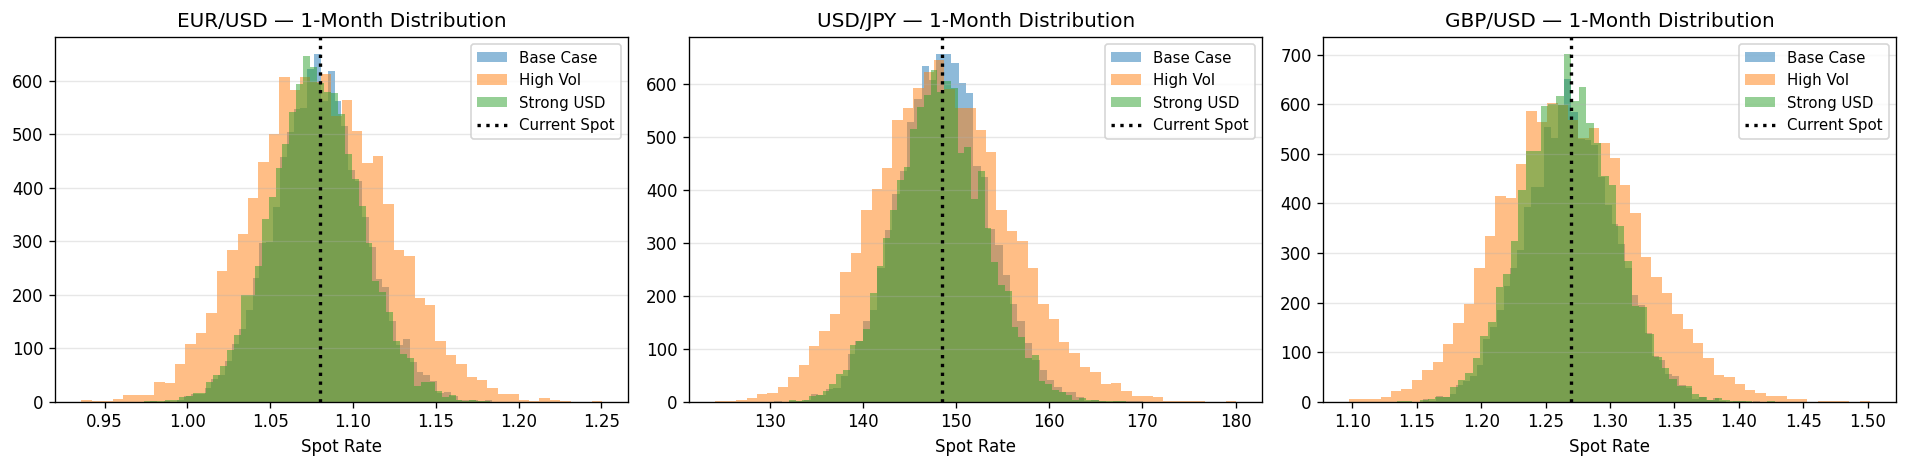

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for idx, (pair, fx) in enumerate(fx_pairs.items()):
    ax = axes[idx]
    for s_idx, scen in enumerate(scenarios.keys()):
        vals = end_vals[pair][scen]
        ax.hist(vals, bins=50, alpha=0.5, color=colors[s_idx], label=scen)
    
    ax.axvline(fx["spot"], color="black", ls=":", lw=2, label="Current Spot")
    ax.set_title(f"{pair} — 1-Month Distribution", fontsize=12)
    ax.set_xlabel("Spot Rate")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

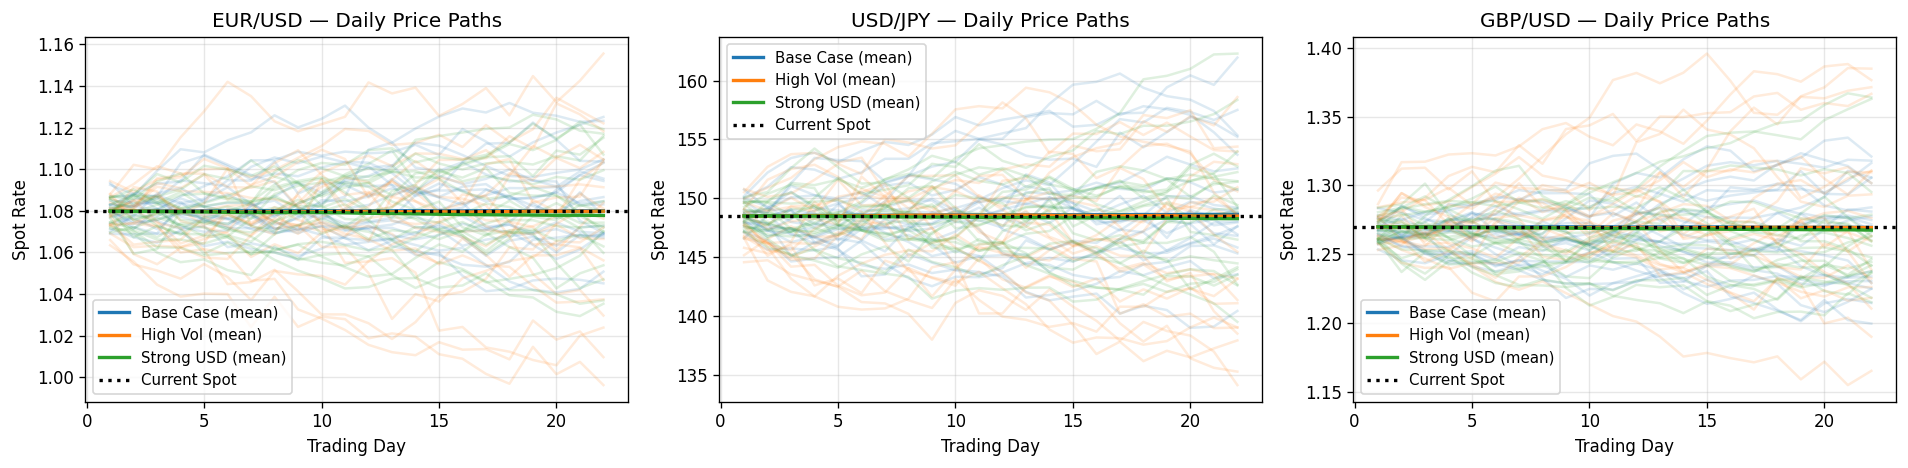

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
days = np.arange(1, t_days + 1)

for idx, (pair, fx) in enumerate(fx_pairs.items()):
    ax = axes[idx]
    for s_idx, scen in enumerate(scenarios.keys()):
        paths = all_paths[pair][scen]
        # Plot a sample of paths
        for i in range(n_plot_paths):
            ax.plot(days, paths[i], color=colors[s_idx], alpha=0.15)
        # Plot mean path
        mean_path = np.mean(paths, axis=0)
        ax.plot(days, mean_path, color=colors[s_idx], lw=2, label=f"{scen} (mean)")
    
    ax.axhline(fx["spot"], color="black", ls=":", lw=2, label="Current Spot")
    ax.set_title(f"{pair} — Daily Price Paths", fontsize=12)
    ax.set_xlabel("Trading Day")
    ax.set_ylabel("Spot Rate")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()